In [26]:
from DinoAINeural import KeyNNClassifier, playGame
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [15]:
with open('data.pkl', 'rb') as file:
        data = pickle.load(file)
    
aiPlayer = KeyNNClassifier(data)
pontos = []
for _ in range(30):
    pontos.append(playGame())

data = {'Meus resultados' : pontos}

df = pd.DataFrame(data)

In [17]:
prof_result = {'Resultados do professor' : [1214.0, 759.5, 1164.25, 977.25, 1201.0, 930.0, 1427.75, 799.5,
1006.25, 783.5, 728.5, 419.25, 1389.5, 730.0, 1306.25, 675.5, 1359.5, 1000.25,
1284.5, 1350.0, 751.0, 1418.75, 1276.5, 1645.75, 860.0, 745.5, 1426.25, 783.5,
1149.75, 1482.25]}

df_prof = pd.DataFrame(prof_result)

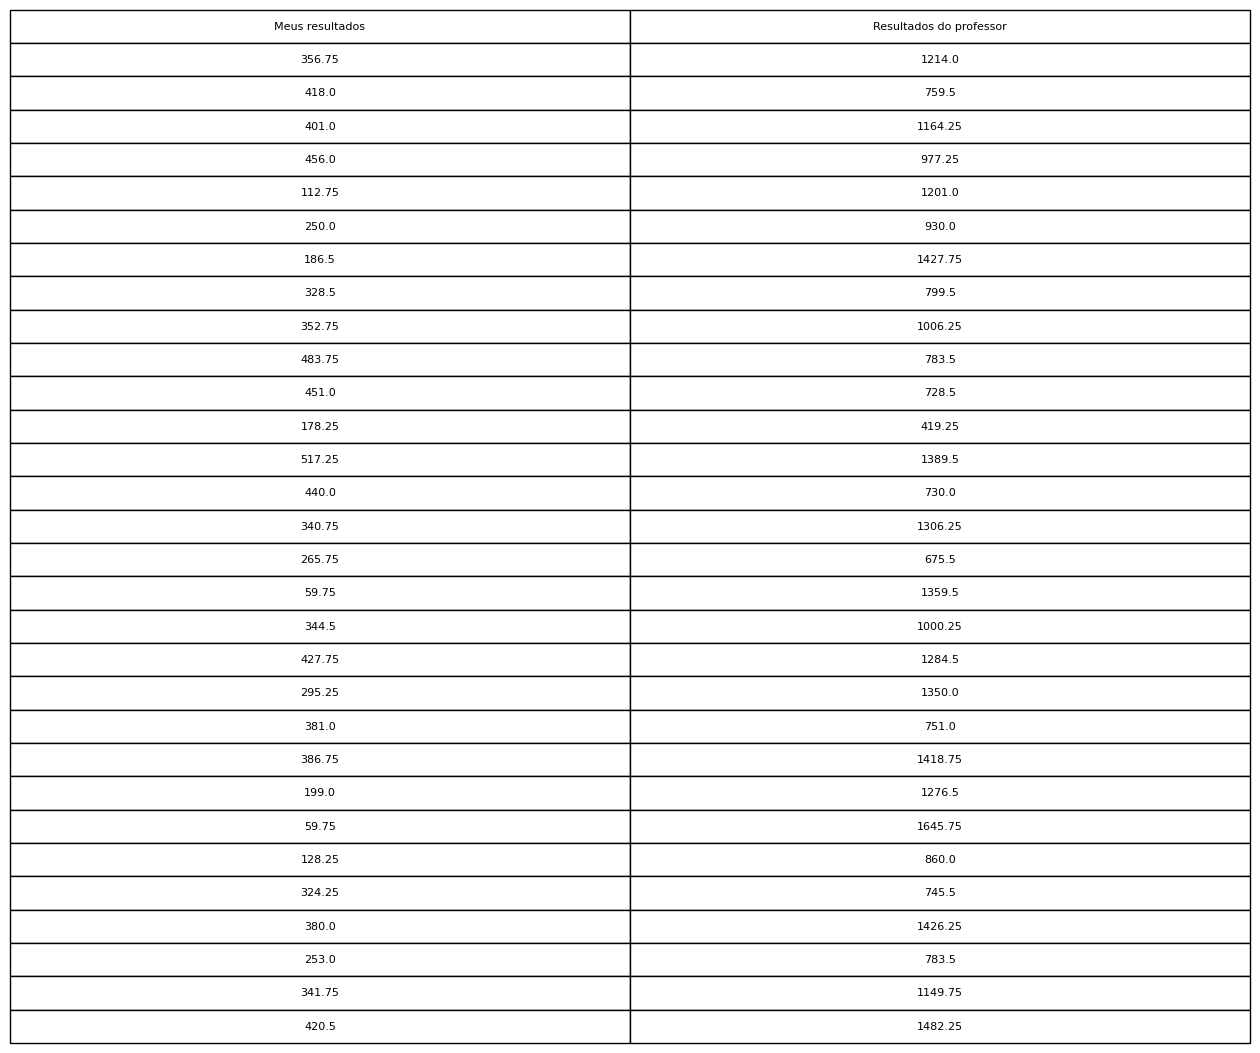

In [24]:
# Configuração da tabela
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
df_combined = pd.concat([df, df_prof], axis=1)
# Transformar o DataFrame em uma tabela do Matplotlib sem incluir os índices das linhas
table = ax.table(cellText=df_combined.values, colLabels=df_combined.columns, cellLoc='center', loc='center')

# Ajustar o tamanho da fonte
table.auto_set_font_size(False)
table.set_fontsize(8)  # Ajuste o tamanho da fonte conforme necessário

# Ajustar o layout
table.scale(2.5, 2)  # Ajuste o fator de escala conforme necessário

plt.show()

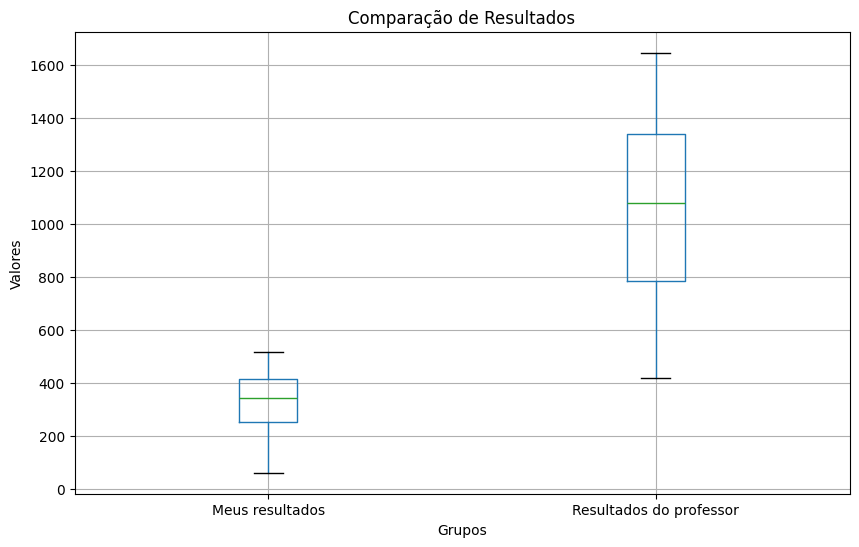

In [21]:
plt.figure(figsize=(10, 6))
df_combined.boxplot()
plt.title('Comparação de Resultados')
plt.ylabel('Pontos')
plt.xlabel('Resultados')
plt.show()


In [27]:
# Realiza o teste t pareado com amostras independentes
t_stat, p_value_ttest = stats.ttest_ind(df['Meus resultados'], df_prof['Resultados do professor'])

# Realiza o teste não paramétrico de Wilcoxon
wilcoxon_stat, p_value_wilcoxon = stats.wilcoxon(df['Meus resultados'], df_prof['Resultados do professor'])

# Nível de significância
alpha = 0.05

# Interpretação dos resultados
print("\nTeste t pareado com amostras independentes")
print(f"t-statistic: {t_stat}, p-value: {p_value_ttest}")
if p_value_ttest < alpha:
    print("Há uma diferença significativa entre os métodos no nível de 95% de significância (Teste t).")
else:
    print("Não há diferença significativa entre os métodos no nível de 95% de significância (Teste t).")

print("\nTeste não paramétrico de Wilcoxon")
print(f"wilcoxon-statistic: {wilcoxon_stat}, p-value: {p_value_wilcoxon}")
if p_value_wilcoxon < alpha:
    print("Há uma diferença significativa entre os métodos no nível de 95% de significância (Teste de Wilcoxon).")
else:
    print("Não há diferença significativa entre os métodos no nível de 95% de significância (Teste de Wilcoxon).")



Teste t pareado com amostras independentes
t-statistic: -12.324742056317666, p-value: 7.708221771129139e-18
Há uma diferença significativa entre os métodos no nível de 95% de significância (Teste t).

Teste não paramétrico de Wilcoxon
wilcoxon-statistic: 0.0, p-value: 1.7343976283205784e-06
Há uma diferença significativa entre os métodos no nível de 95% de significância (Teste de Wilcoxon).
